# 04. Modelagem de PD em 12 meses

Esse notebook treina modelos para estimar a probabilidade de inadimplência em 12 meses.

A ideia é comparar um modelo mais interpretável, como regressão logística, com modelos de árvore/ensemble. O objetivo não é só obter a melhor métrica, mas gerar um score de risco que possa ser transformado depois em uma política de concessão de crédito.

A modelagem vai ser feita com validação temporal, para simular melhor o uso real do modelo: treinar com concessões mais antigas e testar em concessões mais recentes.

In [1]:
# Setup inicial do notebook.
# Uso o renderer com PNG para preservar os gráficos na exportação HTML/PDF.

import sys
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
import optuna

from sklearn.base import clone
from sklearn.model_selection import TimeSeriesSplit

optuna.logging.set_verbosity(optuna.logging.WARNING)

pio.renderers.default = "notebook_connected+png"

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    log_loss,
    confusion_matrix,
    classification_report,
    roc_curve,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC_PATH = PROJECT_ROOT / "src"

if str(SRC_PATH) not in sys.path:
    sys.path.append(str(SRC_PATH))

from concessao_credito.config import (
    PROCESSED_DIR,
    TABLES_DIR,
    FIGURES_DIR,
    MODELS_DIR,
)

from concessao_credito.plots import (
    registrar_template_credito,
    aplicar_layout,
    salvar_figura,
)

registrar_template_credito()

pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", "{:,.4f}".format)

TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("Projeto:", PROJECT_ROOT)
print("Base processada:", PROCESSED_DIR)

Projeto: c:\GitHub\datascience\projetos\concessao_credito
Base processada: C:\GitHub\datascience\projetos\concessao_credito\data\processed


## 1. Leitura da base de modelagem

Eu vou usar a base criada no notebook de target, contendo apenas operações com janela suficiente para observar inadimplência em 12 meses.

In [2]:
# Leio a base de modelagem com target observável em 12 meses.

base_path = PROCESSED_DIR / "base_modelagem_12m.parquet"

base = pd.read_parquet(base_path)

for col in ["data_concessao", "data_nascimento", "data_abertura_conta", "data_ref_12m"]:
    if col in base.columns:
        base[col] = pd.to_datetime(base[col], errors="coerce")

print("Shape da base:", base.shape)
display(base.head())
display(base.dtypes)

Shape da base: (19558, 30)


,id_cliente,data_concessao,valor_emprestado,valor_parcela,valor_taxa,valor_prazo,valor_renda,valor_restritivos,cat_escolaridade,flag_cliente_ativo,cod_agencia,data_nascimento,data_abertura_conta,idade_concessao,tempo_conta_anos,comprometimento_renda,restritivos_sobre_renda,id_operacao,data_ref_12m,tem_janela_12m,flag_inadimplente_12m_observado,target_inadimplente_12m,origem_target_12m,target_inadimplente_ate_12m,fx_valor_renda,fx_valor_emprestado,fx_valor_parcela,fx_comprometimento_renda,fx_valor_restritivos,fx_restritivos_sobre_renda
0,2,2020-10-02,"12,822.7800","1,119.3900",0.0358,15,"4,140.8700",5.2100,Médio Incompleto,1,89,1975-08-01,2019-12-06,45.1718,0.8241,0.2703,0.0013,2,2021-10-31,True,0.0000,0.0000,observado_no_mes_12,0.0000,"(3478.248, 5003.316]","(11630.72, 19467.92]","(1090.946, 1675.716]","(0.258, 0.416]","(4.438, 42.52]","(0.00125, 0.013]"
1,3,2020-10-01,"11,683.1500","1,540.4700",0.0357,9,"2,505.7400",0.0000,Médio Incompleto,1,61,1988-05-03,2019-10-22,32.4134,0.9446,0.6148,0.0000,3,2021-10-31,True,NaN,0.0000,sem_registro_no_mes_12_assumido_quitado,0.0000,"(1804.064, 2575.78]","(11630.72, 19467.92]","(1090.946, 1675.716]","(0.58, 0.74]","(-0.001, 4.438]","(-0.001, 0.00125]"
2,9,2020-06-05,"29,299.1400","3,143.7900",0.0412,12,"4,807.5400",15.7800,Fundamental Incompleto,0,61,1976-11-09,2018-11-23,43.5702,1.5332,0.6539,0.0033,9,2021-06-30,True,0.0000,0.0000,observado_no_mes_12,0.0000,"(3478.248, 5003.316]","(19467.92, 162511.33]","(2655.548, 23401.53]","(0.58, 0.74]","(4.438, 42.52]","(0.00125, 0.013]"
3,12,2021-04-01,"18,797.4200","2,823.7100",0.0427,8,"3,427.1200",0.0000,Sem Escolaridade,1,63,2003-04-02,2020-10-04,17.9986,0.4901,0.8239,0.0000,12,2022-04-30,True,NaN,0.0000,sem_registro_no_mes_12_assumido_quitado,0.0000,"(2575.78, 3478.248]","(11630.72, 19467.92]","(2655.548, 23401.53]","(0.74, 0.9]","(-0.001, 4.438]","(-0.001, 0.00125]"
4,15,2020-09-29,"11,975.9300","1,248.9700",0.0363,12,"1,663.7500",21.5600,Não Declarado,1,28,1985-03-25,2017-11-28,35.5154,2.8364,0.7507,0.0130,15,2021-09-30,True,0.0000,0.0000,observado_no_mes_12,0.0000,"(1199.999, 1804.064]","(11630.72, 19467.92]","(1090.946, 1675.716]","(0.74, 0.9]","(4.438, 42.52]","(0.00125, 0.013]"


id_cliente                                  int64
data_concessao                     datetime64[us]
valor_emprestado                          float64
valor_parcela                             float64
valor_taxa                                float64
valor_prazo                                 int64
valor_renda                               float64
valor_restritivos                         float64
cat_escolaridade                           string
flag_cliente_ativo                          int64
cod_agencia                                 int64
data_nascimento                    datetime64[us]
data_abertura_conta                datetime64[us]
idade_concessao                           float64
tempo_conta_anos                          float64
comprometimento_renda                     float64
restritivos_sobre_renda                   float64
id_operacao                                 int64
data_ref_12m                       datetime64[us]
tem_janela_12m                               bool


## 2. Seleção de variáveis

A modelagem tem que usar apenas informações disponíveis no momento da concessão.

Por isso, eu vou excluir variáveis criadas depois da concessão, como origem do target, flags observadas na inadimplência e colunas auxiliares de faixas usadas apenas na EDA.

In [3]:
# Target principal do modelo.
target_col = "target_inadimplente_12m"

# Variáveis numéricas disponíveis no momento da concessão.
features_numericas = [
    "valor_emprestado",
    "valor_parcela",
    "valor_taxa",
    "valor_prazo",
    "valor_renda",
    "valor_restritivos",
    "idade_concessao",
    "tempo_conta_anos",
    "comprometimento_renda",
    "restritivos_sobre_renda",
]

# Variáveis categóricas/cadastrais.
# eu não vou usar cod_agencia no primeiro modelo para evitar que a política fique muito dependente
# de uma variável operacional. Ela pode ser testada depois como análise de sensibilidade.
features_categoricas = [
    "cat_escolaridade",
    "flag_cliente_ativo",
]

features_modelo = features_numericas + features_categoricas

# Faço uma checagem simples para garantir que todas as variáveis existem na base.
features_faltantes = [col for col in features_modelo if col not in base.columns]

print("Features faltantes:", features_faltantes)

if features_faltantes:
    raise ValueError("Existem features faltantes na base de modelagem.")

# Base final para treino.
df_modelo = base[features_modelo + [target_col, "data_concessao", "id_operacao"]].copy()

df_modelo[target_col] = df_modelo[target_col].astype(int)

display(df_modelo.head())

Features faltantes: []


,valor_emprestado,valor_parcela,valor_taxa,valor_prazo,valor_renda,valor_restritivos,idade_concessao,tempo_conta_anos,comprometimento_renda,restritivos_sobre_renda,cat_escolaridade,flag_cliente_ativo,target_inadimplente_12m,data_concessao,id_operacao
0,"12,822.7800","1,119.3900",0.0358,15,"4,140.8700",5.2100,45.1718,0.8241,0.2703,0.0013,Médio Incompleto,1,0,2020-10-02,2
1,"11,683.1500","1,540.4700",0.0357,9,"2,505.7400",0.0000,32.4134,0.9446,0.6148,0.0000,Médio Incompleto,1,0,2020-10-01,3
2,"29,299.1400","3,143.7900",0.0412,12,"4,807.5400",15.7800,43.5702,1.5332,0.6539,0.0033,Fundamental Incompleto,0,0,2020-06-05,9
3,"18,797.4200","2,823.7100",0.0427,8,"3,427.1200",0.0000,17.9986,0.4901,0.8239,0.0000,Sem Escolaridade,1,0,2021-04-01,12
4,"11,975.9300","1,248.9700",0.0363,12,"1,663.7500",21.5600,35.5154,2.8364,0.7507,0.0130,Não Declarado,1,0,2020-09-29,15


## 3. Separação temporal entre treino e teste

Como o problema é de crédito, eu vou usar uma separação temporal: treino com concessões mais antigas e teste com concessões mais recentes.

Essa abordagem é mais realista do que um split aleatório, porque simula a aplicação do modelo em safras futuras.

In [4]:
# Ordeno a base pela data de concessão para fazer o corte temporal.

df_modelo = df_modelo.sort_values("data_concessao").reset_index(drop=True)

# Uso 75% das concessões mais antigas para treino e 25% mais recentes para teste.
idx_corte = int(len(df_modelo) * 0.75)
data_corte = df_modelo.loc[idx_corte, "data_concessao"]

df_train = df_modelo[df_modelo["data_concessao"] <= data_corte].copy()
df_test = df_modelo[df_modelo["data_concessao"] > data_corte].copy()

X_train = df_train[features_modelo]
y_train = df_train[target_col]

X_test = df_test[features_modelo]
y_test = df_test[target_col]

resumo_split = pd.DataFrame({
    "base": ["treino", "teste"],
    "qtd_operacoes": [len(df_train), len(df_test)],
    "data_min": [df_train["data_concessao"].min(), df_test["data_concessao"].min()],
    "data_max": [df_train["data_concessao"].max(), df_test["data_concessao"].max()],
    "taxa_inadimplencia": [y_train.mean(), y_test.mean()],
})

display(resumo_split)

resumo_split.to_csv(
    TABLES_DIR / "modelagem_resumo_split_temporal.csv",
    index=False,
    encoding="utf-8-sig",
)

,base,qtd_operacoes,data_min,data_max,taxa_inadimplencia
0,treino,14696,2019-08-20,2021-02-02,0.1231
1,teste,4862,2021-02-03,2021-07-30,0.1230


## 4. Pré-processamento

Eu vou fazer o pré-processamento dentro de um `Pipeline`, para evitar vazamento de informação.

As variáveis numéricas recebem imputação pela mediana e padronização. As variáveis categóricas recebem imputação pela moda e one-hot encoding.

In [5]:
# Pipeline para variáveis numéricas.
# A mediana é mais robusta a outliers do que a média.

prep_numerico = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

# Pipeline para variáveis categóricas.
# O handle_unknown="ignore" evita erro caso apareça uma categoria nova no teste.

prep_categorico = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

# ColumnTransformer aplica cada tratamento no grupo correto de colunas.
preprocessador = ColumnTransformer(
    transformers=[
        ("num", prep_numerico, features_numericas),
        ("cat", prep_categorico, features_categoricas),
    ]
)

## 5. Definição dos modelos

Eu vou comparar três modelos:

1. Regressão logística: mais interpretável e tradicional em credit scoring;
2. Random Forest: modelo de árvore com boa capacidade não linear;
3. Gradient Boosting: modelo de boosting para capturar relações mais complexas.

A decisão final não vai ser baseada só em performance desses modelos, eu também vou usar o critério de interpretabilidade e facilidade de transformar o score em política.

In [6]:
# Defino modelos com parâmetros conservadores.
# A ideia aqui é criar uma primeira comparação sólida, não fazer tuning fino ainda.

modelos = {
    "logistica": LogisticRegression(
        max_iter=2000,
        solver="lbfgs",
        class_weight=None,
        random_state=1995,
    ),
    "random_forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=6,
        min_samples_leaf=50,
        class_weight="balanced_subsample",
        random_state=1995,
        n_jobs=-1,
    ),
    "gradient_boosting": GradientBoostingClassifier(
        n_estimators=250,
        learning_rate=0.05,
        max_depth=3,
        random_state=1995,
    ),
}

pipelines = {}

for nome, modelo in modelos.items():
    pipelines[nome] = Pipeline(steps=[
        ("preprocessador", preprocessador),
        ("modelo", modelo),
    ])

print("Modelos definidos:", list(pipelines.keys()))

Modelos definidos: ['logistica', 'random_forest', 'gradient_boosting']


## 6. Funções de avaliação

As métricas principais vão ser:

- AUC ROC: capacidade geral de ordenação;
- Average Precision: útil para classe positiva minoritária;
- KS: métrica comum em crédito para medir separação entre bons e maus;
- Brier Score: qualidade probabilística do score;
- Log Loss: penaliza probabilidades muito confiantes e erradas.

Também vou gerar análises por decis de score, que é importante para transformar o modelo em política.

In [7]:
def calcular_ks(y_true, y_score):
    """
    Calcula KS a partir da curva ROC.
    """
    fpr, tpr, _ = roc_curve(y_true, y_score)
    return np.max(tpr - fpr)


def avaliar_modelo(nome_modelo, modelo, X_train, y_train, X_test, y_test):
    """
    Treina o modelo e calcula métricas em treino e teste.
    """

    modelo.fit(X_train, y_train)

    pred_train = modelo.predict_proba(X_train)[:, 1]
    pred_test = modelo.predict_proba(X_test)[:, 1]

    metricas = {
        "modelo": nome_modelo,
        "auc_train": roc_auc_score(y_train, pred_train),
        "auc_test": roc_auc_score(y_test, pred_test),
        "ap_train": average_precision_score(y_train, pred_train),
        "ap_test": average_precision_score(y_test, pred_test),
        "ks_train": calcular_ks(y_train, pred_train),
        "ks_test": calcular_ks(y_test, pred_test),
        "brier_test": brier_score_loss(y_test, pred_test),
        "logloss_test": log_loss(y_test, pred_test),
    }

    predicoes = pd.DataFrame({
        "id_operacao": df_test["id_operacao"].values,
        "data_concessao": df_test["data_concessao"].values,
        "y_true": y_test.values,
        "pd_score": pred_test,
        "modelo": nome_modelo,
    })

    return metricas, predicoes


def criar_tabela_decis(predicoes):
    """
    Cria tabela de risco por decis de score.

    O decil 1 representa os clientes de maior risco previsto.
    """
    df = predicoes.copy()

    df["decil_score"] = pd.qcut(
        df["pd_score"].rank(method="first", ascending=False),
        q=10,
        labels=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    )

    tabela = (
        df
        .groupby("decil_score", observed=True, as_index=False)
        .agg(
            qtd_operacoes=("id_operacao", "count"),
            pd_media=("pd_score", "mean"),
            taxa_inadimplencia=("y_true", "mean"),
            qtd_inadimplentes=("y_true", "sum"),
        )
    )

    tabela["taxa_inadimplencia_pct"] = tabela["taxa_inadimplencia"] * 100
    tabela["pd_media_pct"] = tabela["pd_media"] * 100

    return tabela

## 7. Treinamento e comparação dos modelos

Agora eu treino os modelos e comparo as métricas em treino e teste.

O ponto principal aqui é tentar verificara a separação de risco fora da amostra, não só olhando performance do treino.

In [8]:
# Treino todos os modelos definidos e guardo métricas e predições.

metricas_modelos = []
predicoes_modelos = []

for nome, pipeline in pipelines.items():
    print(f"Treinando modelo: {nome}")

    metricas, predicoes = avaliar_modelo(
        nome,
        pipeline,
        X_train,
        y_train,
        X_test,
        y_test,
    )

    metricas_modelos.append(metricas)
    predicoes_modelos.append(predicoes)

metricas_df = pd.DataFrame(metricas_modelos).sort_values("auc_test", ascending=False)
predicoes_df = pd.concat(predicoes_modelos, ignore_index=True)

display(metricas_df)

metricas_df.to_csv(
    TABLES_DIR / "modelagem_metricas_modelos.csv",
    index=False,
    encoding="utf-8-sig",
)

predicoes_df.to_csv(
    TABLES_DIR / "modelagem_predicoes_teste.csv",
    index=False,
    encoding="utf-8-sig",
)

Treinando modelo: logistica
Treinando modelo: random_forest
Treinando modelo: gradient_boosting


,modelo,auc_train,auc_test,ap_train,ap_test,ks_train,ks_test,brier_test,logloss_test
2,gradient_boosting,0.9041,0.8720,0.6310,0.5433,0.6512,0.5915,0.0778,0.2589
1,random_forest,0.8788,0.8579,0.5524,0.5096,0.5929,0.5761,0.1559,0.4791
0,logistica,0.8394,0.8370,0.4569,0.4549,0.5193,0.5250,0.0848,0.2837


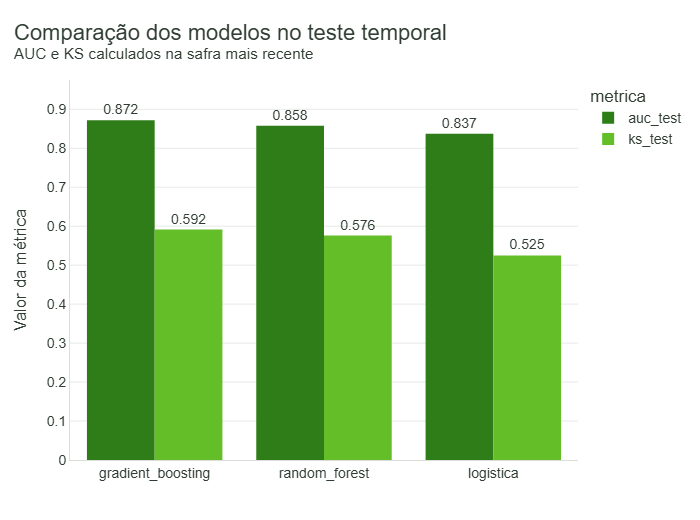

In [9]:
# Comparo AUC e KS no teste, que são métricas úteis para avaliar ordenação do risco.

metricas_plot = metricas_df.melt(
    id_vars="modelo",
    value_vars=["auc_test", "ks_test"],
    var_name="metrica",
    value_name="valor",
)

fig = px.bar(
    metricas_plot,
    x="modelo",
    y="valor",
    color="metrica",
    barmode="group",
    text="valor",
)

fig = aplicar_layout(
    fig,
    titulo="Comparação dos modelos no teste temporal",
    subtitulo="AUC e KS calculados na safra mais recente",
    mostrar_legenda=True,
)

fig.update_traces(
    texttemplate="%{text:.3f}",
    textposition="outside",
)

fig.update_xaxes(title="")
fig.update_yaxes(title="Valor da métrica")

fig.show()

salvar_figura(
    fig,
    caminho_html=FIGURES_DIR / "04_comparacao_modelos_auc_ks.html",
)

## 8. Otimização de hiperparâmetros com Optuna

Depois dos modelos baseline, eu vou fazer uma etapa de otimização de hiperparâmetros.

Eu vou fazer essa otimização só dentro da base de treino, usando validação temporal, isso vai evitar que a safra de teste influencie a busca dos melhores parâmetros.

A métrica principal da otimização vai ser AUC ROC, porque neste problema o score precisa principalmente ordenar clientes de maior e menor risco. A escolha final, porém, não será baseada só em AUC: também vou avaliar KS, Average Precision, Brier Score, Log Loss e indícios de overfitting.

### 8.1 Função de validação temporal para o Optuna

A validação temporal usa apenas a base de treino e respeita a ordem das concessões.

Isso é importante porque, em crédito, o modelo será usado em safras futuras. Portanto, a validação precisa simular esse comportamento: treinar com concessões mais antigas e validar em concessões posteriores.

In [10]:
def auc_cv_temporal(pipeline, X, y, n_splits=4):
    """
    calcula AUC média usando validação temporal.

    uso essa função dentro do Optuna para evitar que a otimização olhe
    para a safra final de teste.
    """
    tscv = TimeSeriesSplit(n_splits=n_splits)
    aucs = []

    for train_idx, valid_idx in tscv.split(X):
        X_tr = X.iloc[train_idx]
        X_val = X.iloc[valid_idx]

        y_tr = y.iloc[train_idx]
        y_val = y.iloc[valid_idx]

        modelo_fold = clone(pipeline)
        modelo_fold.fit(X_tr, y_tr)

        pred_val = modelo_fold.predict_proba(X_val)[:, 1]

        aucs.append(roc_auc_score(y_val, pred_val))

    return float(np.mean(aucs))

### 8.2 Otimização da Regressão Logística

Na regressão logística, vou otimizar a força de regularização e o tratamento de desbalanceamento.

A regressão logística continua sendo um modelo importante porque é mais simples de explicar e costuma funcionar bem como referência em problemas de score de crédito.

In [11]:
def objective_logistica(trial):
    """
    Otimiza hiperparâmetros da regressão logística.
    """
    C = trial.suggest_float("C", 1e-3, 10.0, log=True)
    class_weight_opcao = trial.suggest_categorical(
        "class_weight",
        ["none", "balanced"],
    )

    class_weight = None if class_weight_opcao == "none" else "balanced"

    modelo = LogisticRegression(
        C=C,
        penalty="l2",
        solver="lbfgs",
        max_iter=3000,
        class_weight=class_weight,
        random_state=1995,
    )

    pipeline = Pipeline(steps=[
        ("preprocessador", preprocessador),
        ("modelo", modelo),
    ])

    return auc_cv_temporal(
        pipeline=pipeline,
        X=X_train,
        y=y_train,
        n_splits=4,
    )


study_logistica = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=1995),
)

study_logistica.optimize(
    objective_logistica,
    n_trials=30,
    show_progress_bar=True,
)

print("Melhor AUC CV - Logística:", study_logistica.best_value)
print("Melhores parâmetros - Logística:")
display(study_logistica.best_params)

  0%|          | 0/30 [00:00<?, ?it/s]

c:\GitHub\datascience\projetos\concessao_credito\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\GitHub\datascience\projetos\concessao_credito\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


Melhor AUC CV - Logística: 0.8373952365167143
Melhores parâmetros - Logística:


c:\GitHub\datascience\projetos\concessao_credito\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\GitHub\datascience\projetos\concessao_credito\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


{'C': 2.4453358776088296, 'class_weight': 'balanced'}

### 8.3 Otimização da Random Forest

Na Random Forest, vou controlar principalmente a profundidade das árvores, o tamanho mínimo das folhas e o número de árvores.

Esses parâmetros são importantes porque reduzem o risco de o modelo decorar padrões específicos da base de treino.

In [12]:
def objective_random_forest(trial):
    """
    Otimiza hiperparâmetros da Random Forest.
    """
    modelo = RandomForestClassifier(
        n_estimators=trial.suggest_int("n_estimators", 200, 700, step=100),
        max_depth=trial.suggest_int("max_depth", 3, 12),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 20, 200, step=20),
        max_features=trial.suggest_categorical(
            "max_features",
            ["sqrt", "log2", 0.5, None],
        ),
        class_weight=trial.suggest_categorical(
            "class_weight",
            ["balanced", "balanced_subsample"],
        ),
        random_state=1995,
        n_jobs=-1,
    )

    pipeline = Pipeline(steps=[
        ("preprocessador", preprocessador),
        ("modelo", modelo),
    ])

    return auc_cv_temporal(
        pipeline=pipeline,
        X=X_train,
        y=y_train,
        n_splits=4,
    )


study_rf = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=1995),
)

study_rf.optimize(
    objective_random_forest,
    n_trials=30,
    show_progress_bar=True,
)

print("Melhor AUC CV - Random Forest:", study_rf.best_value)
print("Melhores parâmetros - Random Forest:")
display(study_rf.best_params)

  0%|          | 0/30 [00:00<?, ?it/s]

Melhor AUC CV - Random Forest: 0.8602672930191649
Melhores parâmetros - Random Forest:


{'n_estimators': 500,
 'max_depth': 10,
 'min_samples_leaf': 40,
 'max_features': 'log2',
 'class_weight': 'balanced_subsample'}

### 8.4 Otimização do Gradient Boosting

No Gradient Boosting, os principais pontos são número de árvores, taxa de aprendizado, profundidade das árvores e tamanho mínimo das folhas.

A ideia é buscar um modelo com boa capacidade de capturar relações não lineares, mas ainda com controle de complexidade.

In [13]:
def objective_gradient_boosting(trial):
    """
    Otimiza hiperparâmetros do Gradient Boosting.
    """
    modelo = GradientBoostingClassifier(
        n_estimators=trial.suggest_int("n_estimators", 100, 600, step=50),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
        max_depth=trial.suggest_int("max_depth", 2, 5),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 20, 200, step=20),
        subsample=trial.suggest_float("subsample", 0.70, 1.00),
        max_features=trial.suggest_categorical(
            "max_features",
            ["sqrt", "log2", None],
        ),
        random_state=1995,
    )

    pipeline = Pipeline(steps=[
        ("preprocessador", preprocessador),
        ("modelo", modelo),
    ])

    return auc_cv_temporal(
        pipeline=pipeline,
        X=X_train,
        y=y_train,
        n_splits=4,
    )


study_gb = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42),
)

study_gb.optimize(
    objective_gradient_boosting,
    n_trials=30,
    show_progress_bar=True,
)

print("Melhor AUC CV - Gradient Boosting:", study_gb.best_value)
print("Melhores parâmetros - Gradient Boosting:")
display(study_gb.best_params)

  0%|          | 0/30 [00:00<?, ?it/s]

Melhor AUC CV - Gradient Boosting: 0.8727313037458391
Melhores parâmetros - Gradient Boosting:


{'n_estimators': 550,
 'learning_rate': 0.013016483446508815,
 'max_depth': 3,
 'min_samples_leaf': 20,
 'subsample': 0.7353207242496258,
 'max_features': 'sqrt'}

### 8.5 Resumo dos estudos de otimização

Aqui consolido a melhor AUC média encontrada em validação temporal para cada família de modelo.

Essa tabela não escolhe o modelo final sozinha. Ela mostra apenas o desempenho durante a busca de hiperparâmetros dentro do treino.

In [14]:
resumo_optuna = pd.DataFrame([
    {
        "modelo": "logistica_optuna",
        "melhor_auc_cv": study_logistica.best_value,
        "melhores_parametros": study_logistica.best_params,
    },
    {
        "modelo": "random_forest_optuna",
        "melhor_auc_cv": study_rf.best_value,
        "melhores_parametros": study_rf.best_params,
    },
    {
        "modelo": "gradient_boosting_optuna",
        "melhor_auc_cv": study_gb.best_value,
        "melhores_parametros": study_gb.best_params,
    },
])

display(resumo_optuna)

resumo_optuna.to_csv(
    TABLES_DIR / "modelagem_resumo_optuna.csv",
    index=False,
    encoding="utf-8-sig",
)

,modelo,melhor_auc_cv,melhores_parametros
0,logistica_optuna,0.8374,"{'C': 2.4453358776088296, 'class_weight': 'bal..."
1,random_forest_optuna,0.8603,"{'n_estimators': 500, 'max_depth': 10, 'min_sa..."
2,gradient_boosting_optuna,0.8727,"{'n_estimators': 550, 'learning_rate': 0.01301..."


## 9. Avaliação dos modelos otimizados no teste temporal

Depois de encontrar os melhores hiperparâmetros dentro do treino, eu vou avaliar os modelos otimizados na safra de teste.

Esse teste temporal é a avaliação mais importante da modelagem, porque simula melhor o uso do modelo em concessões futuras.

In [15]:
def construir_logistica_otimizada(best_params):
    class_weight = None if best_params["class_weight"] == "none" else "balanced"

    modelo = LogisticRegression(
        C=best_params["C"],
        penalty="l2",
        solver="lbfgs",
        max_iter=3000,
        class_weight=class_weight,
        random_state= 1995,
    )

    return Pipeline(steps=[
        ("preprocessador", preprocessador),
        ("modelo", modelo),
    ])


def construir_random_forest_otimizada(best_params):
    modelo = RandomForestClassifier(
        n_estimators=best_params["n_estimators"],
        max_depth=best_params["max_depth"],
        min_samples_leaf=best_params["min_samples_leaf"],
        max_features=best_params["max_features"],
        class_weight=best_params["class_weight"],
        random_state=1995,
        n_jobs=-1,
    )

    return Pipeline(steps=[
        ("preprocessador", preprocessador),
        ("modelo", modelo),
    ])


def construir_gradient_boosting_otimizado(best_params):
    modelo = GradientBoostingClassifier(
        n_estimators=best_params["n_estimators"],
        learning_rate=best_params["learning_rate"],
        max_depth=best_params["max_depth"],
        min_samples_leaf=best_params["min_samples_leaf"],
        subsample=best_params["subsample"],
        max_features=best_params["max_features"],
        random_state=1995,
    )

    return Pipeline(steps=[
        ("preprocessador", preprocessador),
        ("modelo", modelo),
    ])


pipelines_otimizados = {
    "logistica_optuna": construir_logistica_otimizada(study_logistica.best_params),
    "random_forest_optuna": construir_random_forest_otimizada(study_rf.best_params),
    "gradient_boosting_optuna": construir_gradient_boosting_otimizado(study_gb.best_params),
}

metricas_otimizadas = []
predicoes_otimizadas = []

for nome, pipeline in pipelines_otimizados.items():
    print(f"Avaliando modelo otimizado: {nome}")

    metricas, predicoes = avaliar_modelo(
        nome,
        pipeline,
        X_train,
        y_train,
        X_test,
        y_test,
    )

    metricas_otimizadas.append(metricas)
    predicoes_otimizadas.append(predicoes)

metricas_otimizadas_df = pd.DataFrame(metricas_otimizadas)
predicoes_otimizadas_df = pd.concat(predicoes_otimizadas, ignore_index=True)

display(metricas_otimizadas_df.sort_values("auc_test", ascending=False))

Avaliando modelo otimizado: logistica_optuna
Avaliando modelo otimizado: random_forest_optuna


c:\GitHub\datascience\projetos\concessao_credito\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


Avaliando modelo otimizado: gradient_boosting_optuna


,modelo,auc_train,auc_test,ap_train,ap_test,ks_train,ks_test,brier_test,logloss_test
2,gradient_boosting_optuna,0.8907,0.8739,0.5907,0.5494,0.6175,0.5900,0.0774,0.2591
1,random_forest_optuna,0.9037,0.8625,0.6033,0.5156,0.6481,0.5741,0.1397,0.4340
0,logistica_optuna,0.8408,0.8372,0.4461,0.4434,0.5232,0.5274,0.1673,0.5090


## 10. Comparação entre baseline e modelos otimizados

Agora junto os modelos baseline e os modelos otimizados.

A escolha final vai ser feita com base no teste temporal, porque ele representa a capacidade do modelo de generalizar para uma safra futura.

In [16]:
metricas_baseline_df = metricas_df.copy()
metricas_baseline_df["tipo_modelo"] = "baseline"

metricas_otimizadas_df["tipo_modelo"] = "optuna"

metricas_comparacao = pd.concat(
    [metricas_baseline_df, metricas_otimizadas_df],
    ignore_index=True,
)

metricas_comparacao = metricas_comparacao.sort_values(
    ["auc_test", "ks_test"],
    ascending=False,
).reset_index(drop=True)

predicoes_comparacao = pd.concat(
    [predicoes_df, predicoes_otimizadas_df],
    ignore_index=True,
)

display(metricas_comparacao)

metricas_comparacao.to_csv(
    TABLES_DIR / "modelagem_metricas_modelos_com_optuna.csv",
    index=False,
    encoding="utf-8-sig",
)

predicoes_comparacao.to_csv(
    TABLES_DIR / "modelagem_predicoes_teste_com_optuna.csv",
    index=False,
    encoding="utf-8-sig",
)

,modelo,auc_train,auc_test,ap_train,ap_test,ks_train,ks_test,brier_test,logloss_test,tipo_modelo
0,gradient_boosting_optuna,0.8907,0.8739,0.5907,0.5494,0.6175,0.5900,0.0774,0.2591,optuna
1,gradient_boosting,0.9041,0.8720,0.6310,0.5433,0.6512,0.5915,0.0778,0.2589,baseline
2,random_forest_optuna,0.9037,0.8625,0.6033,0.5156,0.6481,0.5741,0.1397,0.4340,optuna
3,random_forest,0.8788,0.8579,0.5524,0.5096,0.5929,0.5761,0.1559,0.4791,baseline
4,logistica_optuna,0.8408,0.8372,0.4461,0.4434,0.5232,0.5274,0.1673,0.5090,optuna
5,logistica,0.8394,0.8370,0.4569,0.4549,0.5193,0.5250,0.0848,0.2837,baseline


### 10.1 Métricas usadas para escolher o modelo

A escolha do modelo candidato considera seis critérios:

1. **AUC no teste**: principal métrica de ordenação de risco;
2. **KS no teste**: mede a separação entre bons e maus pagadores;
3. **Average Precision no teste**: útil porque inadimplentes são minoria;
4. **Brier Score no teste**: mede se a probabilidade estimada é confiável;
5. **Log Loss no teste**: penaliza probabilidades muito confiantes e erradas;
6. **Gap entre AUC de treino e teste**: ajuda a identificar overfitting.

Não uso acurácia como critério principal porque a base é desbalanceada. Um modelo pode ter boa acurácia simplesmente por prever muitos clientes como adimplentes, mas isso não necessariamente ajuda na política de crédito.

In [17]:
metricas_escolha = metricas_comparacao.copy()

# Gap positivo muito alto pode indicar que o modelo aprendeu bem demais o treino,
# mas perdeu capacidade de generalização no teste.
metricas_escolha["gap_auc_train_test"] = (
    metricas_escolha["auc_train"] - metricas_escolha["auc_test"]
)

# Para métricas em que maior é melhor.
metricas_escolha["rank_auc"] = metricas_escolha["auc_test"].rank(
    ascending=False,
    method="min",
)

metricas_escolha["rank_ks"] = metricas_escolha["ks_test"].rank(
    ascending=False,
    method="min",
)

metricas_escolha["rank_ap"] = metricas_escolha["ap_test"].rank(
    ascending=False,
    method="min",
)

# Para métricas em que menor é melhor.
metricas_escolha["rank_brier"] = metricas_escolha["brier_test"].rank(
    ascending=True,
    method="min",
)

metricas_escolha["rank_logloss"] = metricas_escolha["logloss_test"].rank(
    ascending=True,
    method="min",
)

metricas_escolha["rank_gap"] = metricas_escolha["gap_auc_train_test"].abs().rank(
    ascending=True,
    method="min",
)

# Ranking ponderado.
# Quanto menor o score_escolha, melhor.
metricas_escolha["score_escolha"] = (
    0.35 * metricas_escolha["rank_auc"] +
    0.25 * metricas_escolha["rank_ks"] +
    0.10 * metricas_escolha["rank_ap"] +
    0.15 * metricas_escolha["rank_brier"] +
    0.10 * metricas_escolha["rank_logloss"] +
    0.05 * metricas_escolha["rank_gap"]
)

metricas_escolha = metricas_escolha.sort_values(
    "score_escolha",
    ascending=True,
).reset_index(drop=True)

cols_ranking = [
    "modelo",
    "tipo_modelo",
    "score_escolha",
    "auc_test",
    "ks_test",
    "ap_test",
    "brier_test",
    "logloss_test",
    "gap_auc_train_test",
    "auc_train",
]

display(metricas_escolha[cols_ranking])

metricas_escolha.to_csv(
    TABLES_DIR / "modelagem_ranking_escolha_modelo.csv",
    index=False,
    encoding="utf-8-sig",
)

,modelo,tipo_modelo,score_escolha,auc_test,ks_test,ap_test,brier_test,logloss_test,gap_auc_train_test,auc_train
0,gradient_boosting_optuna,optuna,1.4500,0.8739,0.5900,0.5494,0.0774,0.2591,0.0169,0.8907
1,gradient_boosting,baseline,1.8000,0.8720,0.5915,0.5433,0.0778,0.2589,0.0321,0.9041
2,random_forest_optuna,optuna,3.6500,0.8625,0.5741,0.5156,0.1397,0.4340,0.0412,0.9037
3,random_forest,baseline,4.0000,0.8579,0.5761,0.5096,0.1559,0.4791,0.0209,0.8788
4,logistica,baseline,4.9000,0.8370,0.5250,0.4549,0.0848,0.2837,0.0024,0.8394
5,logistica_optuna,optuna,5.2000,0.8372,0.5274,0.4434,0.1673,0.5090,0.0036,0.8408


### 10.2 Visualização da comparação final

O gráfico abaixo compara AUC e KS no teste temporal.

Essas duas métricas são as mais úteis para verificar se o score consegue separar clientes de maior e menor risco.

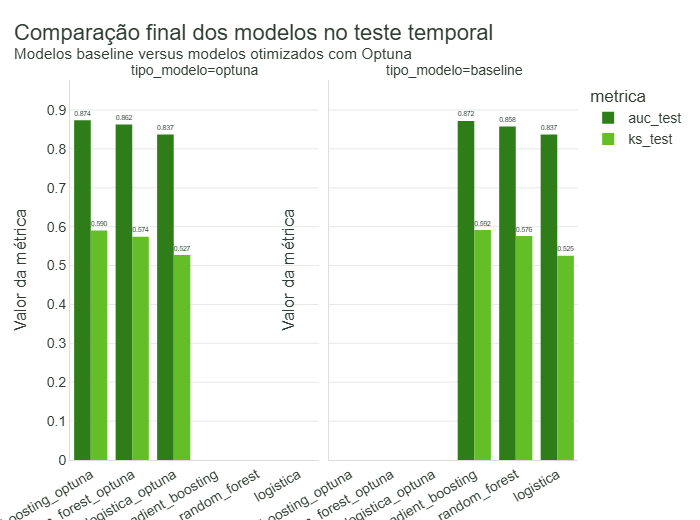

In [18]:
metricas_plot_final = metricas_comparacao.melt(
    id_vars=["modelo", "tipo_modelo"],
    value_vars=["auc_test", "ks_test"],
    var_name="metrica",
    value_name="valor",
)

fig = px.bar(
    metricas_plot_final,
    x="modelo",
    y="valor",
    color="metrica",
    barmode="group",
    text="valor",
    facet_col="tipo_modelo",
)

fig = aplicar_layout(
    fig,
    titulo="Comparação final dos modelos no teste temporal",
    subtitulo="Modelos baseline versus modelos otimizados com Optuna",
    mostrar_legenda=True,
)

fig.update_traces(
    texttemplate="%{text:.3f}",
    textposition="outside",
)

fig.update_xaxes(title="", tickangle=-30)
fig.update_yaxes(title="Valor da métrica")

fig.show()

salvar_figura(
    fig,
    caminho_html=FIGURES_DIR / "04_comparacao_final_modelos_optuna.html",
)

## 11. Escolha do modelo candidato

A escolha do modelo candidato vai ser feita pelo menor `score_escolha`.

Esse critério prioriza AUC e KS, porque o score precisa ordenar bem o risco, mas também considera métricas probabilísticas, porque a PD estimada será usada depois para construir faixas de aprovação, revisão, recusa e limite máximo.

In [19]:
todos_pipelines = {}
todos_pipelines.update(pipelines)
todos_pipelines.update(pipelines_otimizados)

melhor_modelo_nome = metricas_escolha.iloc[0]["modelo"]
melhor_modelo = todos_pipelines[melhor_modelo_nome]

pred_melhor = predicoes_comparacao[
    predicoes_comparacao["modelo"] == melhor_modelo_nome
].copy()

print("Modelo candidato escolhido:", melhor_modelo_nome)

display(
    metricas_escolha.loc[
        metricas_escolha["modelo"] == melhor_modelo_nome,
        cols_ranking,
    ]
)

display(pred_melhor.head())

Modelo candidato escolhido: gradient_boosting_optuna


,modelo,tipo_modelo,score_escolha,auc_test,ks_test,ap_test,brier_test,logloss_test,gap_auc_train_test,auc_train
0,gradient_boosting_optuna,optuna,1.4500,0.8739,0.5900,0.5494,0.0774,0.2591,0.0169,0.8907


,id_operacao,data_concessao,y_true,pd_score,modelo
24310,25527,2021-02-03,0,0.0486,gradient_boosting_optuna
24311,20641,2021-02-03,0,0.0233,gradient_boosting_optuna
24312,5207,2021-02-03,0,0.0735,gradient_boosting_optuna
24313,18223,2021-02-03,0,0.0291,gradient_boosting_optuna
24314,22025,2021-02-03,0,0.0215,gradient_boosting_optuna


## 12. Análise por decis de score

A análise por decis mostra se os clientes com maior score previsto realmente têm maior inadimplência observada.

Essa etapa é essencial para transformar o modelo em uma política de concessão.

In [20]:
# Crio a tabela de decis do melhor modelo.
# O primeiro decil deve concentrar maior inadimplência se o modelo estiver ordenando bem o risco.

decis_melhor = criar_tabela_decis(pred_melhor)

display(decis_melhor)

decis_melhor.to_csv(
    TABLES_DIR / "modelagem_decis_melhor_modelo.csv",
    index=False,
    encoding="utf-8-sig",
)

,decil_score,qtd_operacoes,pd_media,taxa_inadimplencia,qtd_inadimplentes,taxa_inadimplencia_pct,pd_media_pct
0,1,487,0.5224,0.5606,273,56.0575,52.2443
1,2,486,0.2557,0.2901,141,29.0123,25.5730
2,3,486,0.1480,0.1481,72,14.8148,14.7976
3,4,486,0.0989,0.0967,47,9.6708,9.8936
4,5,486,0.0703,0.0494,24,4.9383,7.0327
5,6,486,0.0510,0.0412,20,4.1152,5.1041
6,7,486,0.0359,0.0206,10,2.0576,3.5863
7,8,486,0.0252,0.0165,8,1.6461,2.5220
8,9,486,0.0188,0.0062,3,0.6173,1.8802
9,10,487,0.0100,0.0000,0,0.0000,0.9979


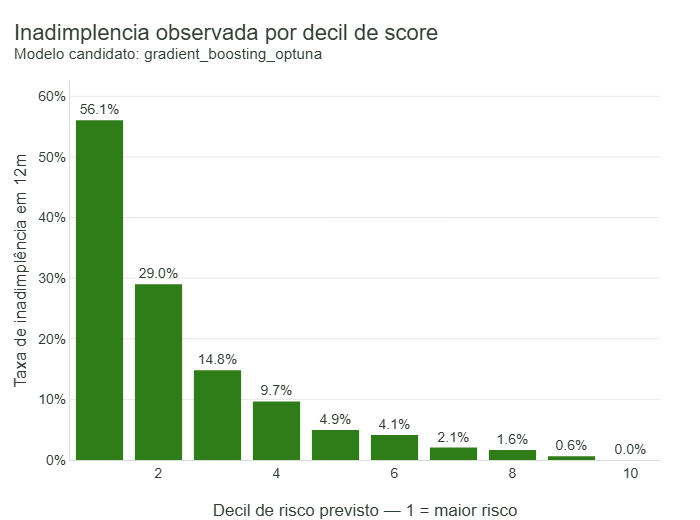

In [21]:
# Gráfico da taxa observada por decil de score.
# A expectativa é uma queda gradual da inadimplência do decil 1 para o decil 10.

fig = px.bar(
    decis_melhor,
    x="decil_score",
    y="taxa_inadimplencia_pct",
    text="taxa_inadimplencia_pct",
)

fig = aplicar_layout(
    fig,
    titulo="Inadimplencia observada por decil de score",
    subtitulo=f"Modelo candidato: {melhor_modelo_nome}",
    mostrar_legenda=False,
)

fig.update_traces(
    texttemplate="%{text:.1f}%",
    textposition="outside",
)

fig.update_xaxes(title="Decil de risco previsto — 1 = maior risco")
fig.update_yaxes(title="Taxa de inadimplência em 12m", ticksuffix="%")

fig.show()

salvar_figura(
    fig,
    caminho_html=FIGURES_DIR / "04_inadimplencia_por_decil_score.html",
)

## 13. Curva ROC do melhor modelo

A curva ROC ajuda a visualizar a capacidade de separação entre bons e maus pagadores.

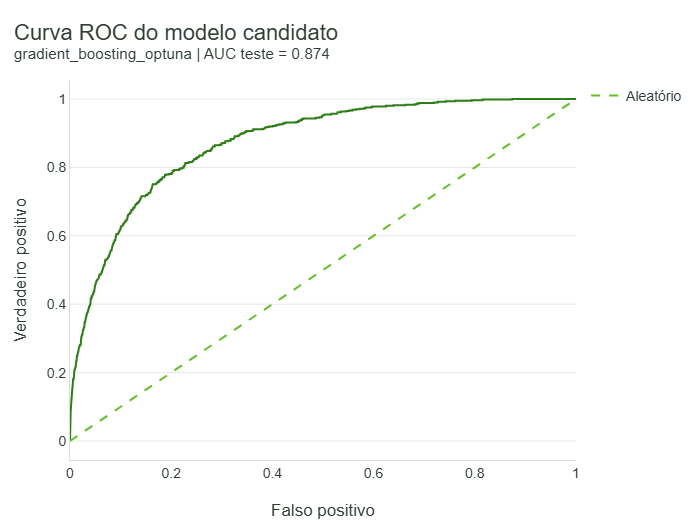

In [22]:
# Calculo a curva ROC do melhor modelo no teste temporal.

fpr, tpr, thresholds = roc_curve(
    pred_melhor["y_true"],
    pred_melhor["pd_score"],
)

auc_melhor = roc_auc_score(
    pred_melhor["y_true"],
    pred_melhor["pd_score"],
)

roc_df = pd.DataFrame({
    "fpr": fpr,
    "tpr": tpr,
    "threshold": thresholds,
})

fig = px.line(
    roc_df,
    x="fpr",
    y="tpr",
)

# Linha de referência de um modelo aleatório.
fig.add_trace(
    go.Scatter(
        x=[0, 1],
        y=[0, 1],
        mode="lines",
        name="Aleatório",
        line=dict(dash="dash"),
    )
)

fig = aplicar_layout(
    fig,
    titulo="Curva ROC do modelo candidato",
    subtitulo=f"{melhor_modelo_nome} | AUC teste = {auc_melhor:.3f}",
    mostrar_legenda=True,
)

fig.update_xaxes(title="Falso positivo")
fig.update_yaxes(title="Verdadeiro positivo")

fig.show()

salvar_figura(
    fig,
    caminho_html=FIGURES_DIR / "04_curva_roc_melhor_modelo.html",
)

## 14. Matriz de confusão com corte inicial

Para transformar o score em decisão, preciso definir um ponto de corte.

Nesta primeira leitura, uso um corte simples pela taxa média de inadimplência prevista no teste. A política final será definida depois com base em faixas de risco e capacidade de pagamento.

In [23]:
# Uso um corte inicial apenas para interpretar a matriz de confusão.
# A decisão final será feita por faixas de risco, não por um único threshold fixo.

threshold_inicial = pred_melhor["pd_score"].mean()

pred_melhor["pred_classe"] = np.where(
    pred_melhor["pd_score"] >= threshold_inicial,
    1,
    0,
)

matriz = confusion_matrix(
    pred_melhor["y_true"],
    pred_melhor["pred_classe"],
)

matriz_df = pd.DataFrame(
    matriz,
    index=["Real adimplente", "Real inadimplente"],
    columns=["Predito adimplente", "Predito inadimplente"],
)

display(matriz_df)

print("Threshold inicial:", threshold_inicial)
print(classification_report(pred_melhor["y_true"], pred_melhor["pred_classe"]))

,Predito adimplente,Predito inadimplente
Real adimplente,3331,933
Real inadimplente,122,476


Threshold inicial: 0.12369032516732932
              precision    recall  f1-score   support

           0       0.96      0.78      0.86      4264
           1       0.34      0.80      0.47       598

    accuracy                           0.78      4862
   macro avg       0.65      0.79      0.67      4862
weighted avg       0.89      0.78      0.82      4862



## 15. Salvamento do modelo candidato

Salvo o pipeline completo do melhor modelo, incluindo pré-processamento e estimador.

Isso facilita reproduzir o score no próximo notebook, onde a probabilidade de inadimplência será transformada em política de concessão.

In [24]:
# Salvo o pipeline completo do melhor modelo.
# Assim, no próximo notebook, basta carregar o arquivo e aplicar predict_proba.

modelo_path = MODELS_DIR / f"modelo_pd_12m_{melhor_modelo_nome}.joblib"

joblib.dump(melhor_modelo, modelo_path)

print("Modelo salvo em:", modelo_path)

Modelo salvo em: C:\GitHub\datascience\projetos\concessao_credito\outputs\models\modelo_pd_12m_gradient_boosting_optuna.joblib


## 16. Análise complementar: ordenação do risco por decis

Além das métricas globais, eu avaliei se o score consegue ordenar corretamente os clientes por risco.

Essa análise é mais útil para política de crédito do que olhar apenas a matriz de confusão, porque a decisão final não vai ser baseada em um único corte binário. A política vai ser construída por faixas de risco, combinando PD estimada, capacidade de pagamento e restritivos financeiros.

In [26]:
# Recria a tabela de decis do modelo candidato de forma independente

decis_melhor = pred_melhor.copy()

decis_melhor["decil_risco"] = pd.qcut(
    decis_melhor["pd_score"].rank(method="first", ascending=False),
    q=10,
    labels=False,
) + 1

decis_melhor = (
    decis_melhor
    .groupby("decil_risco")
    .agg(
        qtd_clientes=("y_true", "size"),
        qtd_inadimplentes=("y_true", "sum"),
        pd_media=("pd_score", "mean"),
        pd_min=("pd_score", "min"),
        pd_max=("pd_score", "max"),
        taxa_inadimplencia=("y_true", "mean"),
    )
    .reset_index()
)

decis_melhor["perc_clientes"] = (
    decis_melhor["qtd_clientes"] / decis_melhor["qtd_clientes"].sum()
)

decis_melhor["perc_inadimplentes"] = (
    decis_melhor["qtd_inadimplentes"] / decis_melhor["qtd_inadimplentes"].sum()
)

decis_melhor["perc_inadimplentes_acum"] = (
    decis_melhor["perc_inadimplentes"].cumsum()
)

display(decis_melhor)

decis_melhor.to_csv(
    TABLES_DIR / "modelagem_decis_modelo_candidato.csv",
    index=False,
    encoding="utf-8-sig",
)

,decil_risco,qtd_clientes,qtd_inadimplentes,pd_media,pd_min,pd_max,taxa_inadimplencia,perc_clientes,perc_inadimplentes,perc_inadimplentes_acum
0,1,487,273,0.5224,0.3505,0.9214,0.5606,0.1002,0.4565,0.4565
1,2,486,141,0.2557,0.1859,0.3504,0.2901,0.1000,0.2358,0.6923
2,3,486,72,0.1480,0.1192,0.1857,0.1481,0.1000,0.1204,0.8127
3,4,486,47,0.0989,0.0823,0.1191,0.0967,0.1000,0.0786,0.8913
4,5,486,24,0.0703,0.0600,0.0823,0.0494,0.1000,0.0401,0.9314
5,6,486,20,0.0510,0.0426,0.0600,0.0412,0.1000,0.0334,0.9649
6,7,486,10,0.0359,0.0298,0.0425,0.0206,0.1000,0.0167,0.9816
7,8,486,8,0.0252,0.0215,0.0297,0.0165,0.1000,0.0134,0.9950
8,9,486,3,0.0188,0.0154,0.0215,0.0062,0.1000,0.0050,1.0000
9,10,487,0,0.0100,0.0047,0.0154,0.0000,0.1002,0.0000,1.0000


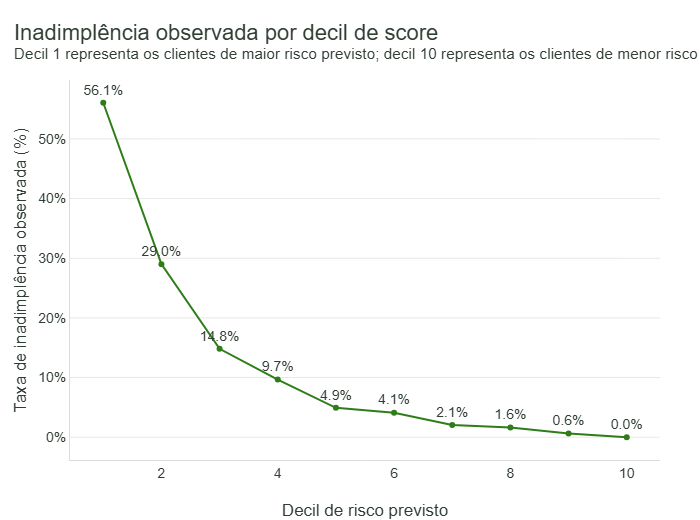

In [27]:
# Gráfico de inadimplência observada por decil de risco

decis_plot = decis_melhor.copy()
decis_plot["taxa_inadimplencia_pct"] = decis_plot["taxa_inadimplencia"] * 100
decis_plot["pd_media_pct"] = decis_plot["pd_media"] * 100
decis_plot["decil_risco"] = decis_plot["decil_risco"].astype(str)

fig = px.line(
    decis_plot,
    x="decil_risco",
    y="taxa_inadimplencia_pct",
    markers=True,
    text="taxa_inadimplencia_pct",
)

fig = aplicar_layout(
    fig,
    titulo="Inadimplência observada por decil de score",
    subtitulo=(
        "Decil 1 representa os clientes de maior risco previsto; "
        "decil 10 representa os clientes de menor risco previsto"
    ),
    mostrar_legenda=False,
)

fig.update_traces(
    texttemplate="%{text:.1f}%",
    textposition="top center",
)

fig.update_xaxes(
    title="Decil de risco previsto",
)

fig.update_yaxes(
    title="Taxa de inadimplência observada (%)",
    ticksuffix="%",
)

fig.show()

salvar_figura(
    fig,
    caminho_html=FIGURES_DIR / "04_inadimplencia_por_decil_score.html",
)

## 17. Sensibilidade do ponto de corte

A matriz de confusão anterior usa um corte inicial apenas para diagnóstico.

Como a classe inadimplente é minoritária, existe um trade-off natural entre precision e recall: quando o corte é mais baixo, o modelo captura mais inadimplentes, mas também classifica mais clientes bons como risco elevado. Quando o corte é mais alto, a precision melhora, mas o modelo deixa passar mais inadimplentes.

Por isso, a política final não deve ser definida por um único threshold. A análise abaixo mostra diferentes cortes possíveis e seus impactos em precision, recall, taxa de aprovação e inadimplência esperada entre aprovados.

In [28]:
from sklearn.metrics import precision_score, recall_score, f1_score

def avaliar_corte_credito(df_pred, threshold):
    """
    Avalia um ponto de corte para classificar clientes como alto risco.

    Regra:
    - pred_classe = 1: cliente classificado como alto risco/inadimplente
    - pred_classe = 0: cliente classificado como baixo risco/adimplente

    Para política:
    - clientes abaixo do corte seriam aprovados automaticamente, em uma leitura simples;
    - clientes acima do corte iriam para recusa, redução de limite ou análise manual.
    """
    temp = df_pred.copy()

    temp["pred_classe"] = np.where(
        temp["pd_score"] >= threshold,
        1,
        0,
    )

    precision = precision_score(
        temp["y_true"],
        temp["pred_classe"],
        zero_division=0,
    )

    recall = recall_score(
        temp["y_true"],
        temp["pred_classe"],
        zero_division=0,
    )

    f1 = f1_score(
        temp["y_true"],
        temp["pred_classe"],
        zero_division=0,
    )

    clientes_aprovados = temp[temp["pd_score"] < threshold]
    clientes_bloqueados = temp[temp["pd_score"] >= threshold]

    taxa_aprovacao = len(clientes_aprovados) / len(temp)

    bad_rate_aprovados = (
        clientes_aprovados["y_true"].mean()
        if len(clientes_aprovados) > 0
        else np.nan
    )

    bad_rate_bloqueados = (
        clientes_bloqueados["y_true"].mean()
        if len(clientes_bloqueados) > 0
        else np.nan
    )

    return {
        "threshold": threshold,
        "precision_inadimplente": precision,
        "recall_inadimplente": recall,
        "f1_inadimplente": f1,
        "taxa_aprovacao_simples": taxa_aprovacao,
        "bad_rate_aprovados": bad_rate_aprovados,
        "bad_rate_bloqueados": bad_rate_bloqueados,
        "qtd_aprovados": len(clientes_aprovados),
        "qtd_bloqueados": len(clientes_bloqueados),
    }


thresholds = [
    pred_melhor["pd_score"].quantile(q)
    for q in [0.50, 0.60, 0.70, 0.75, 0.80, 0.85, 0.90]
]

sensibilidade_corte = pd.DataFrame([
    avaliar_corte_credito(pred_melhor, threshold)
    for threshold in thresholds
])

display(sensibilidade_corte)

sensibilidade_corte.to_csv(
    TABLES_DIR / "modelagem_sensibilidade_threshold.csv",
    index=False,
    encoding="utf-8-sig",
)

,threshold,precision_inadimplente,recall_inadimplente,f1_inadimplente,taxa_aprovacao_simples,bad_rate_aprovados,bad_rate_bloqueados,qtd_aprovados,qtd_bloqueados
0,0.0600,0.2291,0.9314,0.3678,0.5000,0.0169,0.2291,2431,2431
1,0.0823,0.2740,0.8913,0.4192,0.6000,0.0223,0.2740,2917,1945
2,0.1192,0.3331,0.8127,0.4725,0.6999,0.0329,0.3331,3403,1459
3,0.1466,0.3750,0.7625,0.5028,0.7499,0.0389,0.3750,3646,1216
4,0.1859,0.4255,0.6923,0.5271,0.7999,0.0473,0.4255,3889,973
5,0.2482,0.4808,0.5870,0.5286,0.8499,0.0598,0.4808,4132,730
6,0.3505,0.5606,0.4565,0.5032,0.8998,0.0743,0.5606,4375,487


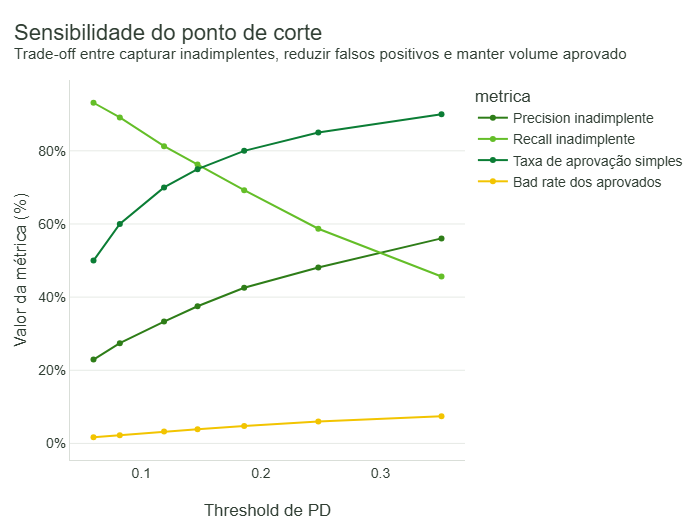

In [29]:
# Visualização do trade-off entre precision e recall

sens_plot = sensibilidade_corte.copy()

sens_plot["threshold_label"] = sens_plot["threshold"].map(lambda x: f"{x:.3f}")
sens_plot["precision_pct"] = sens_plot["precision_inadimplente"] * 100
sens_plot["recall_pct"] = sens_plot["recall_inadimplente"] * 100
sens_plot["taxa_aprovacao_pct"] = sens_plot["taxa_aprovacao_simples"] * 100
sens_plot["bad_rate_aprovados_pct"] = sens_plot["bad_rate_aprovados"] * 100

sens_plot_long = sens_plot.melt(
    id_vars=["threshold_label"],
    value_vars=[
        "precision_pct",
        "recall_pct",
        "taxa_aprovacao_pct",
        "bad_rate_aprovados_pct",
    ],
    var_name="metrica",
    value_name="valor",
)

rotulos_metricas = {
    "precision_pct": "Precision inadimplente",
    "recall_pct": "Recall inadimplente",
    "taxa_aprovacao_pct": "Taxa de aprovação simples",
    "bad_rate_aprovados_pct": "Bad rate dos aprovados",
}

sens_plot_long["metrica"] = sens_plot_long["metrica"].map(rotulos_metricas)

fig = px.line(
    sens_plot_long,
    x="threshold_label",
    y="valor",
    color="metrica",
    markers=True,
)

fig = aplicar_layout(
    fig,
    titulo="Sensibilidade do ponto de corte",
    subtitulo="Trade-off entre capturar inadimplentes, reduzir falsos positivos e manter volume aprovado",
    mostrar_legenda=True,
)

fig.update_xaxes(title="Threshold de PD")
fig.update_yaxes(title="Valor da métrica (%)", ticksuffix="%")

fig.show()

salvar_figura(
    fig,
    caminho_html=FIGURES_DIR / "04_sensibilidade_threshold_precision_recall.html",
)

## 18. Interpretação sobre precision

O precision da classe inadimplente ficou baixo no corte inicial porque o threshold usado é conservador do ponto de vista de risco: ele tenta capturar uma parcela alta dos inadimplentes, aumentando o recall, mas também gera falsos positivos.

Isso não invalida o modelo. Em problemas de crédito, especialmente com classe inadimplente minoritária, precision e recall dependem fortemente do ponto de corte. Por isso, a avaliação principal do modelo não deve ser feita apenas pela matriz de confusão de um corte arbitrário, mas pela capacidade de ordenação do score.

A análise por decis mostra que o modelo separa bem os clientes de maior e menor risco. Portanto, para a política de concessão, a recomendação é transformar a PD em faixas de decisão:

- baixo risco: aprovação automática, respeitando capacidade de pagamento;
- risco intermediário: aprovação com limite reduzido ou análise manual;
- alto risco: recusa ou exigência de condições mais conservadoras.

Dessa forma, o score não será usado como uma decisão binária simples, mas como insumo para definir risco, limite e estratégia de concessão.

## 19. Conclusões da modelagem

A modelagem teve como objetivo estimar a probabilidade de inadimplência em até 12 meses após a concessão.

O modelo candidato escolhido foi o `gradient_boosting_optuna`, por apresentar o melhor equilíbrio entre performance fora da amostra, estabilidade e qualidade probabilística. A análise por decis confirmou que o score ordena bem o risco, concentrando a maior parte dos inadimplentes nos primeiros decis.

O precision baixo no corte inicial não invalida o modelo, pois esse corte foi usado apenas para diagnóstico. Como existe um trade-off entre precision e recall, a política final não deve usar uma decisão binária simples.

No próximo notebook, a PD estimada será combinada com capacidade de pagamento, restritivos financeiros e relacionamento com o banco para definir faixas de aprovação, revisão, recusa e valor máximo concedido.